# Assignment 1: Boston Housing Price Prediction
## Deep Neural Network for Regression

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

Libraries imported successfully!


In [2]:
# Load dataset
# IMPORTANT: Update the path to your CSV file
data = pd.read_csv('boston_housing.csv')

print("Dataset shape:", data.shape)
print("\nFirst 5 rows:")
print(data.head())
print("\nDataset info:")
print(data.describe())

Dataset shape: (506, 14)

First 5 rows:
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  

Dataset info:
             CRIM          ZN       INDUS        CHAS         NOX          RM  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695    6.284634   
std      8.601545   23.322453    6.860353    0.253994    0.115878    0.

In [3]:
# Prepare data
X = data.drop('MEDV', axis=1)  # Features
y = data['MEDV']  # Target (housing price)

# Split into train and test sets (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train_scaled.shape}")
print(f"Test set: {X_test_scaled.shape}")

Training set: (404, 13)
Test set: (102, 13)


In [4]:
# Define hyperparameter configurations to test
configs = [
    {'name': 'Config 1: ReLU, Batch 32', 'activation': 'relu', 'batch_size': 32},
    {'name': 'Config 2: ReLU, Batch 64', 'activation': 'relu', 'batch_size': 64},
    {'name': 'Config 3: ReLU, Batch 128', 'activation': 'relu', 'batch_size': 128},
    {'name': 'Config 4: Tanh, Batch 32', 'activation': 'tanh', 'batch_size': 32},
    {'name': 'Config 5: Tanh, Batch 64', 'activation': 'tanh', 'batch_size': 64},
    {'name': 'Config 6: Sigmoid, Batch 32', 'activation': 'sigmoid', 'batch_size': 32},
]

print("Testing 6 configurations:")
for i, config in enumerate(configs, 1):
    print(f"{i}. {config['name']}")

Testing 6 configurations:
1. Config 1: ReLU, Batch 32
2. Config 2: ReLU, Batch 64
3. Config 3: ReLU, Batch 128
4. Config 4: Tanh, Batch 32
5. Config 5: Tanh, Batch 64
6. Config 6: Sigmoid, Batch 32


In [5]:
# Train models with different configurations
results = []

for config in configs:
    print(f"\n{'='*60}")
    print(f"Training: {config['name']}")
    print(f"{'='*60}")
    
    # Build model
    model = Sequential([
        Dense(64, activation=config['activation'], input_shape=(X_train_scaled.shape[1],)),
        Dense(32, activation=config['activation']),
        Dropout(0.2),
        Dense(1)  # Output layer (no activation for regression)
    ])
    
    # Compile model
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    
    # Train model
    history = model.fit(
        X_train_scaled, y_train,
        epochs=50,
        batch_size=config['batch_size'],
        validation_split=0.2,
        verbose=0
    )
    
    # Evaluate on test set
    predictions = model.predict(X_test_scaled, verbose=0)
    
    # Calculate metrics
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    
    # Store results
    results.append({
        'Config': config['name'],
        'Activation': config['activation'],
        'Batch Size': config['batch_size'],
        'RMSE': rmse,
        'MAE': mae,
        'R2 Score': r2
    })
    
    print(f"✓ RMSE: {rmse:.3f}")
    print(f"✓ MAE: {mae:.3f}")
    print(f"✓ R² Score: {r2:.3f}")

print("\n" + "="*60)
print("All configurations trained!")
print("="*60)


Training: Config 1: ReLU, Batch 32
✓ RMSE: 4.036
✓ MAE: 2.500
✓ R² Score: 0.778

Training: Config 2: ReLU, Batch 64
✓ RMSE: 5.077
✓ MAE: 3.341
✓ R² Score: 0.649

Training: Config 3: ReLU, Batch 128
✓ RMSE: 5.734
✓ MAE: 3.864
✓ R² Score: 0.552

Training: Config 4: Tanh, Batch 32
✓ RMSE: 7.448
✓ MAE: 4.430
✓ R² Score: 0.244

Training: Config 5: Tanh, Batch 64
✓ RMSE: 10.258
✓ MAE: 7.315
✓ R² Score: -0.435

Training: Config 6: Sigmoid, Batch 32
✓ RMSE: 11.255
✓ MAE: 8.334
✓ R² Score: -0.727

All configurations trained!


In [6]:
# Display results table
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('RMSE')
print("\nRESULTS TABLE (Sorted by RMSE):")
print(results_df.to_string(index=False))

# Identify best model
best_config = results_df.iloc[0]
print(f"\n{'='*60}")
print("BEST MODEL:")
print(f"Configuration: {best_config['Config']}")
print(f"RMSE: {best_config['RMSE']:.3f}")
print(f"MAE: {best_config['MAE']:.3f}")
print(f"R² Score: {best_config['R2 Score']:.3f}")
print(f"{'='*60}")


RESULTS TABLE (Sorted by RMSE):
                     Config Activation  Batch Size      RMSE      MAE  R2 Score
   Config 1: ReLU, Batch 32       relu          32  4.036188 2.499853  0.777854
   Config 2: ReLU, Batch 64       relu          64  5.076774 3.340590  0.648544
  Config 3: ReLU, Batch 128       relu         128  5.733975 3.863554  0.551660
   Config 4: Tanh, Batch 32       tanh          32  7.448009 4.429707  0.243557
   Config 5: Tanh, Batch 64       tanh          64 10.258217 7.314680 -0.434960
Config 6: Sigmoid, Batch 32    sigmoid          32 11.254678 8.333756 -0.727277

BEST MODEL:
Configuration: Config 1: ReLU, Batch 32
RMSE: 4.036
MAE: 2.500
R² Score: 0.778


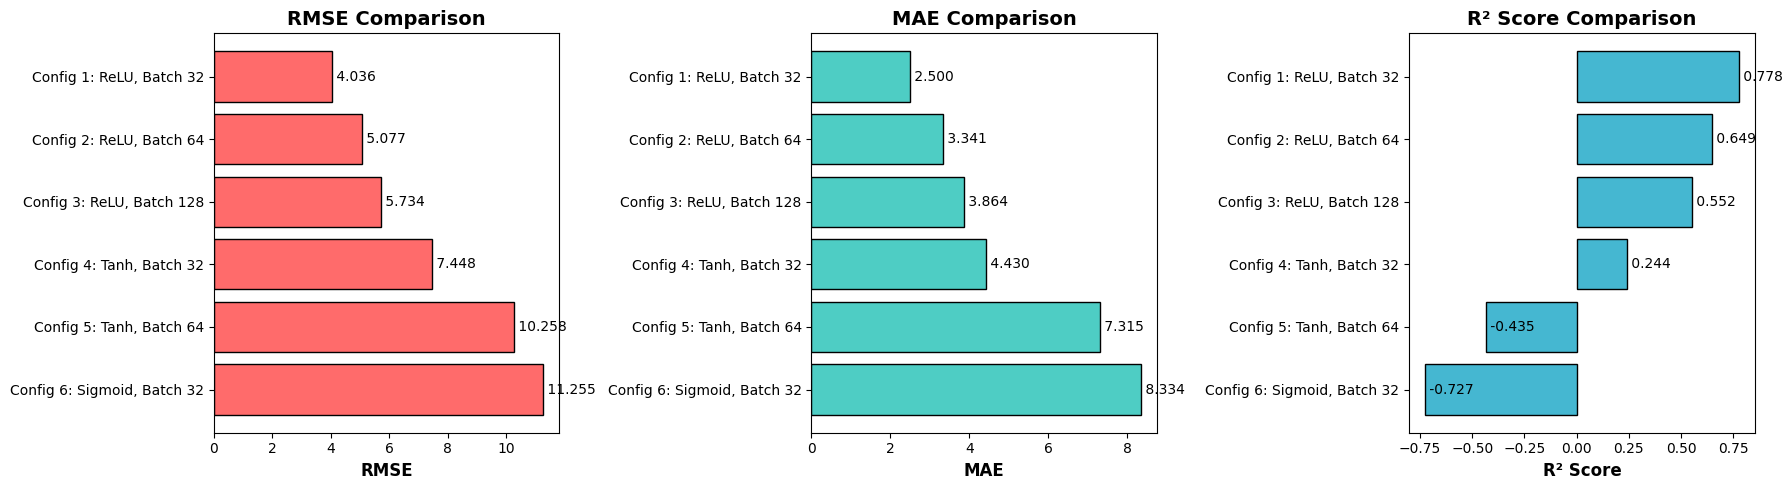

Visualization saved as 'assignment1_results.png'


In [7]:
# Visualize results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# RMSE comparison
axes[0].barh(results_df['Config'], results_df['RMSE'], color='#FF6B6B', edgecolor='black')
axes[0].set_xlabel('RMSE', fontweight='bold', fontsize=12)
axes[0].set_title('RMSE Comparison', fontweight='bold', fontsize=14)
axes[0].invert_yaxis()
for i, v in enumerate(results_df['RMSE']):
    axes[0].text(v, i, f' {v:.3f}', va='center')

# MAE comparison
axes[1].barh(results_df['Config'], results_df['MAE'], color='#4ECDC4', edgecolor='black')
axes[1].set_xlabel('MAE', fontweight='bold', fontsize=12)
axes[1].set_title('MAE Comparison', fontweight='bold', fontsize=14)
axes[1].invert_yaxis()
for i, v in enumerate(results_df['MAE']):
    axes[1].text(v, i, f' {v:.3f}', va='center')

# R² Score comparison
axes[2].barh(results_df['Config'], results_df['R2 Score'], color='#45B7D1', edgecolor='black')
axes[2].set_xlabel('R² Score', fontweight='bold', fontsize=12)
axes[2].set_title('R² Score Comparison', fontweight='bold', fontsize=14)
axes[2].invert_yaxis()
for i, v in enumerate(results_df['R2 Score']):
    axes[2].text(v, i, f' {v:.3f}', va='center')

plt.tight_layout()
plt.savefig('assignment1_results.png', dpi=300, bbox_inches='tight')
plt.show()
print("Visualization saved as 'assignment1_results.png'")

In [8]:
# Train best model for custom testing
best_activation = best_config['Activation']
best_batch_size = int(best_config['Batch Size'])

print(f"Training final model with best configuration...")
print(f"Activation: {best_activation}, Batch Size: {best_batch_size}")

final_model = Sequential([
    Dense(64, activation=best_activation, input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation=best_activation),
    Dropout(0.2),
    Dense(1)
])

final_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
final_model.fit(X_train_scaled, y_train, epochs=50, batch_size=best_batch_size, 
                validation_split=0.2, verbose=0)

print("✓ Final model trained!")

Training final model with best configuration...
Activation: relu, Batch Size: 32
✓ Final model trained!


In [9]:
# Test with custom input (not from training/testing data)
print("\n" + "="*60)
print("TESTING WITH CUSTOM INPUT")
print("="*60)

# Create a custom house with specific features
# Features: [CRIM, ZN, INDUS, CHAS, NOX, RM, AGE, DIS, RAD, TAX, PTRATIO, B, LSTAT]
custom_house = np.array([[
    0.1,      # CRIM: Low crime rate
    20.0,     # ZN: Residential land zoned
    6.0,      # INDUS: Proportion of non-retail business
    0,        # CHAS: Not near Charles River
    0.45,     # NOX: Nitric oxides concentration
    7.5,      # RM: 7.5 rooms (good size)
    40.0,     # AGE: 40% old buildings
    5.0,      # DIS: Distance to employment centers
    4,        # RAD: Accessibility to highways
    300,      # TAX: Property tax
    16.0,     # PTRATIO: Pupil-teacher ratio
    390.0,    # B: Proportion of African Americans
    5.0       # LSTAT: Lower status population %
]])

print("\nCustom House Features:")
feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
for name, value in zip(feature_names, custom_house[0]):
    print(f"  {name:10s}: {value}")

# Scale the custom input
custom_house_scaled = scaler.transform(custom_house)

# Predict
predicted_price = final_model.predict(custom_house_scaled, verbose=0)[0][0]

print(f"\n{'='*60}")
print(f"PREDICTED PRICE: ${predicted_price:.2f}k (${predicted_price*1000:.0f})")
print(f"{'='*60}")

# Compare with similar houses in dataset
print("\nComparison with dataset:")
print(f"  Minimum price in dataset: ${y.min():.2f}k")
print(f"  Average price in dataset: ${y.mean():.2f}k")
print(f"  Maximum price in dataset: ${y.max():.2f}k")
print(f"  Our prediction: ${predicted_price:.2f}k")


TESTING WITH CUSTOM INPUT

Custom House Features:
  CRIM      : 0.1
  ZN        : 20.0
  INDUS     : 6.0
  CHAS      : 0.0
  NOX       : 0.45
  RM        : 7.5
  AGE       : 40.0
  DIS       : 5.0
  RAD       : 4.0
  TAX       : 300.0
  PTRATIO   : 16.0
  B         : 390.0
  LSTAT     : 5.0

PREDICTED PRICE: $35.20k ($35205)

Comparison with dataset:
  Minimum price in dataset: $5.00k
  Average price in dataset: $22.53k
  Maximum price in dataset: $50.00k
  Our prediction: $35.20k


In [10]:
# Save results
results_df.to_csv('assignment1_results.csv', index=False)
print("\nResults saved to 'assignment1_results.csv'")
print("\n✓ Assignment 1 Complete!")


Results saved to 'assignment1_results.csv'

✓ Assignment 1 Complete!
